In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df= pd.read_csv("/content/Mall_Customers.csv")

In [9]:
df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})

In [10]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Gender                  200 non-null    int64
 1   Age                     200 non-null    int64
 2   Annual Income (k$)      200 non-null    int64
 3   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4)
memory usage: 6.4 KB


In [12]:
df.describe()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,0.440000,38.850000,60.560000,50.200000
std,0.497633,13.969007,26.264721,25.823522
min,0.000000,18.000000,15.000000,1.000000
25%,0.000000,28.750000,41.500000,34.750000
50%,0.000000,36.000000,61.500000,50.000000
75%,1.000000,49.000000,78.000000,73.000000
max,1.000000,70.000000,137.000000,99.000000


In [13]:
df.shape

(200, 4)

In [14]:
print(df.isnull().sum())

Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [15]:
print(df.duplicated().sum())

0


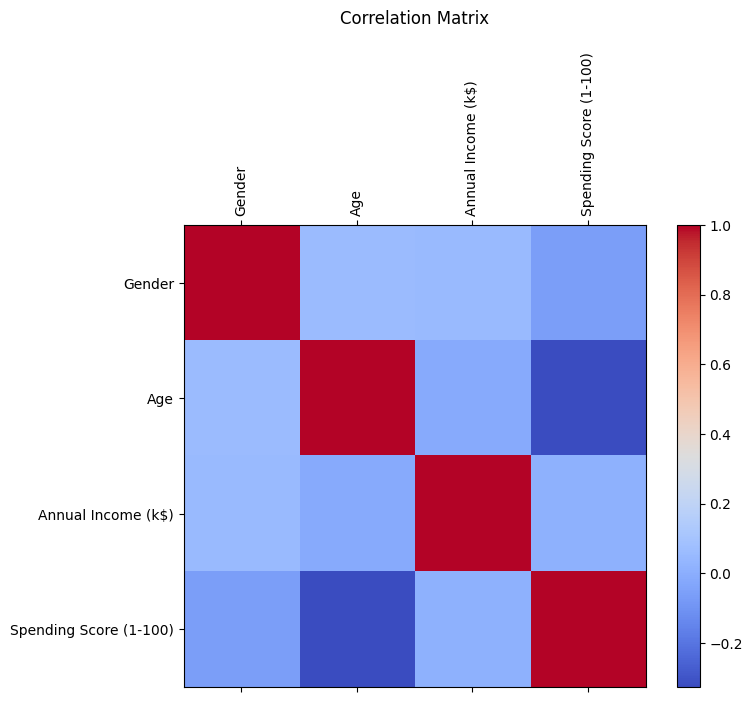

In [16]:
import matplotlib.pyplot as plt

correlation = df.corr()

fig, ax = plt.subplots(figsize=(8,6))

cax = ax.matshow(correlation, cmap="coolwarm")

fig.colorbar(cax)

ax.set_xticks(range(len(correlation.columns)))
ax.set_yticks(range(len(correlation.columns)))

ax.set_xticklabels(correlation.columns, rotation=90)
ax.set_yticklabels(correlation.columns)

plt.title("Correlation Matrix", pad=20)

plt.show()

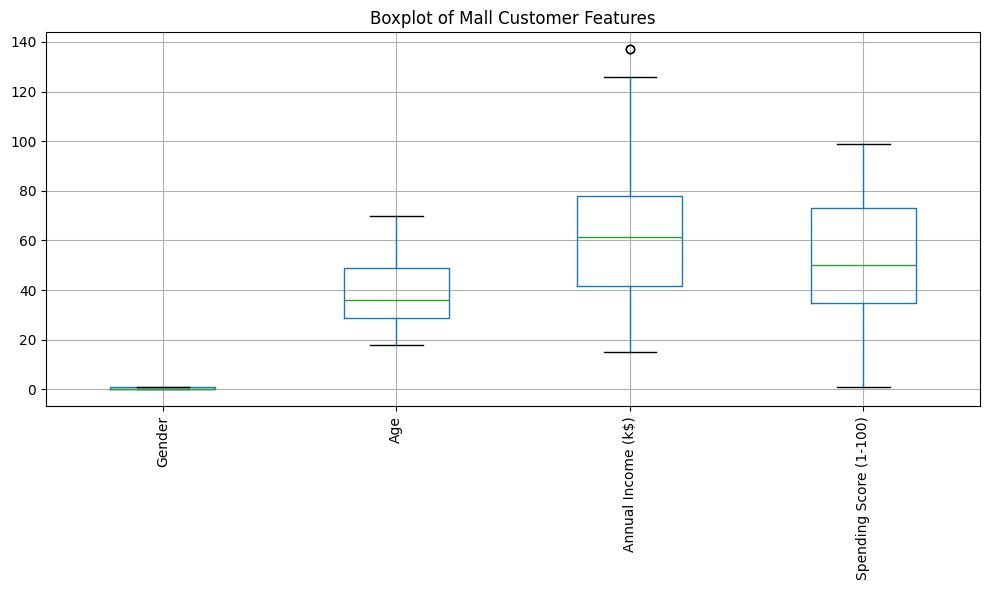

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,6))

df.boxplot(ax=ax)

ax.set_title("Boxplot of Mall Customer Features")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

In [18]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

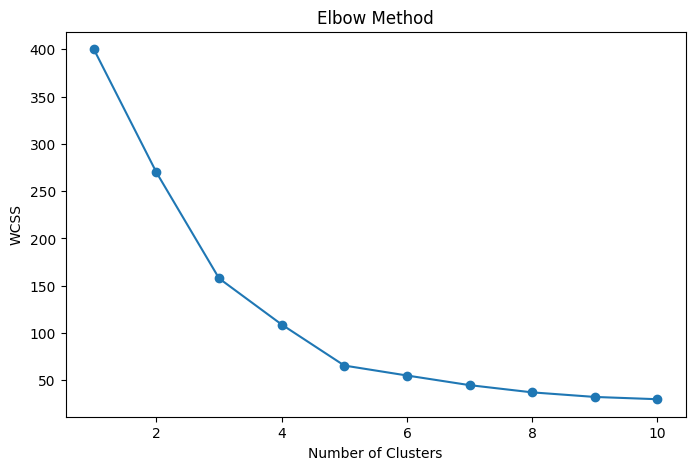

In [20]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [21]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

kmeans.fit(X_scaled)

KMeans(n_clusters=5, n_init=10, random_state=42)

In [22]:
clusters = kmeans.predict(X_scaled)

df["Cluster"] = clusters

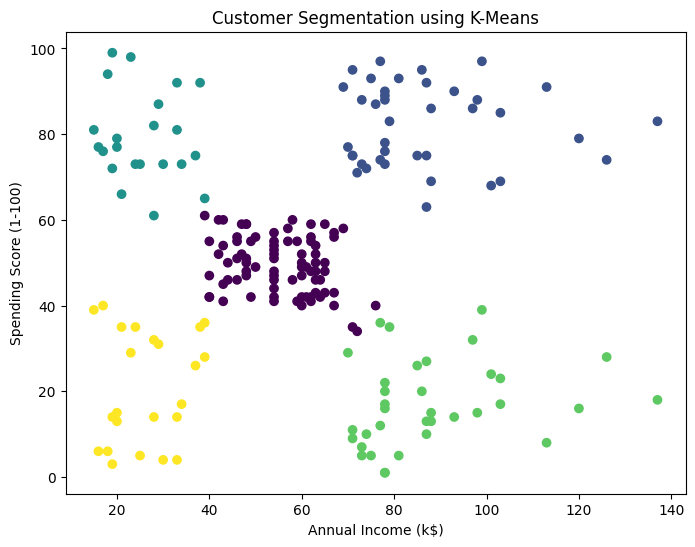

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"]
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation using K-Means")

plt.show()

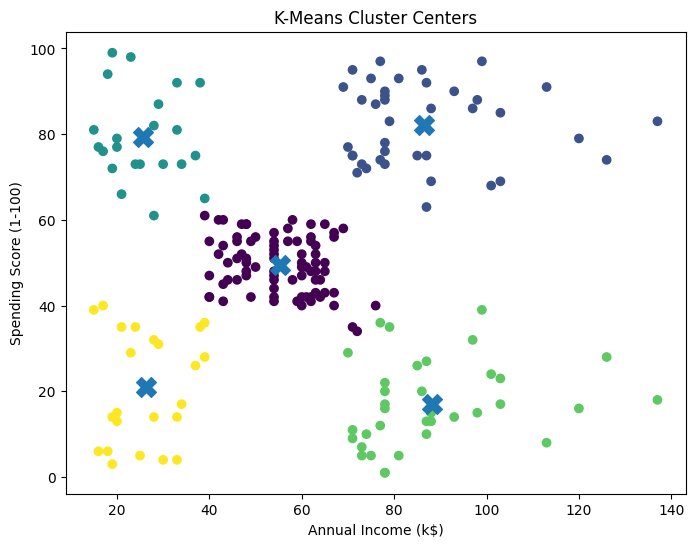

In [24]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)

plt.figure(figsize=(8,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"]
)

plt.scatter(
    centers[:,0],
    centers[:,1],
    s=200,
    marker="X"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("K-Means Cluster Centers")

plt.show()